# Testing Imprecise Scoring Rules on Real Data

**Based on:** *Truthful Elicitation of Imprecise Forecasts* by Singh, Chau & Muandet (2025)

---


## What I am doing and why

The paper proves its randomized scoring rule is strictly proper (Corollary 5.4), but the only empirical evidence is a single synthetic contour at one symmetric interval, $[0.4, 0.6]$. I wanted to know whether the result survives contact with intervals that come from a **real** machine-learning ensemble rather than ones I
chose by hand.

So I ask two concrete questions:

1. When the credal sets are produced by genuine model disagreement, does honesty still pay under the randomized rule?
2. Does the size of that payoff scale with the amount of uncertainty, i.e. with how much the models disagree?

My plan: train five different classifiers, treat their spread of predictions on each patient as a credal set, and then score honest reporting against a "confident lie" under both a fixed rule (dictatorship) and the randomized rule.

> **A note on what this experiment is and isn't.** This is an *elicitation* test, not a training test. I am not training a model to be honest; I am taking an existing set of beliefs (the ensemble's spread) and checking whether the scoring rule would reward reporting that set truthfully. The honest report is always the true credal set so I NEVER optimise it.

## Step 0: Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import os
import warnings
warnings.filterwarnings('ignore')

FIG_DIR = os.path.join(os.getcwd(), "figs")
os.makedirs(FIG_DIR, exist_ok=True)

## Step 1: The data

I use the Wisconsin breast-cancer dataset: 569 patients, 30 numeric features each (cell-nucleus measurements), and a binary label (**malignant (0)** or **benign (1)**). I picked it deliberately: it is a setting where the *cost of false confidence is real*, which is exactly where an honest "I'm not sure, it's somewhere between $a$ and $b$" matters.

In [3]:
data = load_breast_cancer()
print("shape:", data.data.shape)
print("classes:", list(data.target_names), "(0 = malignant, 1 = benign)")
print(f"overall balance: {data.target.mean():.2%} benign")

X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\ntrain: {X_train.shape[0]} | test: {X_test.shape[0]} "
      f"| test balance: {y_test.mean():.2%} benign")

shape: (569, 30)
classes: [np.str_('malignant'), np.str_('benign')] (0 = malignant, 1 = benign)
overall balance: 62.74% benign

train: 455 | test: 114 | test balance: 62.28% benign


> I standardise the features (fit on train only, then apply to test) because two of my five models (KNN and logistic regression) are scale-sensitive. The 80/20 split with a fixed seed makes the whole notebook reproducible.

## Step 2: Five classifiers with different inductive biases

I train five models that "think" differently: a linear model, two tree ensembles, a distance-based model, and a probabilistic one. The point is **not** that some are good and some are bad, they are all strong here (94–97%). The point is that different biases make them *disagree on the hard cases*, and that disagreement is what gives me a non-trivial credal set per patient.

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Gaussian NB": GaussianNB(),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"  {name:<22s} accuracy = {acc:.4f}")

  Logistic Regression    accuracy = 0.9737
  Random Forest          accuracy = 0.9649
  Gradient Boosting      accuracy = 0.9561
  KNN (k=5)              accuracy = 0.9474
  Gaussian NB            accuracy = 0.9649


> All five sit between 94.7% and 97.4%. So when they disagree on a patient, it is not one broken model dragging the others, it is five competent models that genuinely read an ambiguous case differently. That is precisely the situation imprecise probability is meant to describe.

## Step 3: From disagreement to credal sets

For each test patient, the five models each output $P(\text{benign})$. I take the **range** of those five numbers — $[\min, \max]$ — as the patient's credal set. A narrow range means the models agree (near-precise belief); a wide range means they don't (genuine epistemic uncertainty).

In [6]:
all_probs = np.column_stack([
    model.predict_proba(X_test)[:, 1] for model in models.values()
])
credal_sets = np.column_stack([all_probs.min(axis=1), all_probs.max(axis=1)])
widths = credal_sets[:, 1] - credal_sets[:, 0]

## Step 4: Looking at the credal sets *before* scoring anything

Before I score anything, I want to actually see what these intervals look like, because the whole story depends on their shape.

In [7]:
print("credal-set widths across the 114 test patients")
print(f"  mean   {widths.mean():.4f}")
print(f"  median {np.median(widths):.4f}")
print(f"  min    {widths.min():.4f}")
print(f"  max    {widths.max():.4f}")
print(f"  share below 0.05 : {(widths < 0.05).mean():.1%}")
print(f"  share above 0.30 : {(widths > 0.30).mean():.1%}  "
      f"({int((widths > 0.30).sum())} patients)")

credal-set widths across the 114 test patients
  mean   0.0892
  median 0.0100
  min    0.0002
  max    0.7832
  share below 0.05 : 68.4%
  share above 0.30 : 7.0%  (8 patients)


> **This is the key shape of the data.** The *typical* patient has an almost degenerate credal set — median width 0.01, and two-thirds are below 0.05. The models agree on the easy cases. But there is a heavy tail: 8 patients have width above 0.30, up to a maximum of 0.78. The uncertainty is real but *rare*, so concentrated on a handful of genuinely ambiguous cases. We should keep this split in mind, because it is exactly where the scoring rule will and won't matter.

### The width distribution

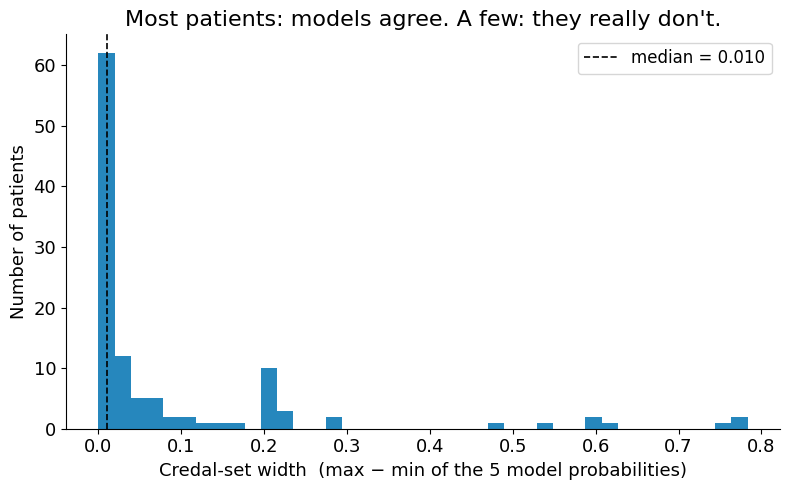

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(widths, bins=40, color="#0072B2", alpha=0.85)
ax.axvline(np.median(widths), color="black", linestyle="--", linewidth=1.2,
           label=f"median = {np.median(widths):.3f}")
ax.set_xlabel("Credal-set width  (max − min of the 5 model probabilities)", fontsize=13)
ax.set_ylabel("Number of patients", fontsize=13)
ax.set_title("Most patients: models agree. A few: they really don't.", fontsize=16)
ax.legend(fontsize=12, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "width_histogram.pdf"), bbox_inches="tight", dpi=150)
plt.show()

### A concrete wide case vs a concrete narrow case

To make the credal sets tangible, I look at the single widest patient and a typical (median-width) one, and print what each model actually said.

In [20]:
def show_patient(i, tag):
    print(f"{tag}: patient index {i} | true label = "
          f"{'benign' if y_test[i]==1 else 'malignant'}")
    for name, p in zip(models.keys(), all_probs[i]):
        print(f"    {name:<22s} P(benign) = {p:.4f}")
    print(f"    -> credal set [{credal_sets[i,0]:.4f}, {credal_sets[i,1]:.4f}]  "
          f"width {widths[i]:.4f}\n")

show_patient(widths.argmax(), "WIDEST  (max disagreement)")
show_patient(np.argsort(widths)[len(widths)//2], "TYPICAL (median width)")

WIDEST  (max disagreement): patient index 52 | true label = benign
    Logistic Regression    P(benign) = 0.6918
    Random Forest          P(benign) = 0.8000
    Gradient Boosting      P(benign) = 0.9832
    KNN (k=5)              P(benign) = 0.2000
    Gaussian NB            P(benign) = 0.9740
    -> credal set [0.2000, 0.9832]  width 0.7832

TYPICAL (median width): patient index 55 | true label = benign
    Logistic Regression    P(benign) = 0.9905
    Random Forest          P(benign) = 0.9900
    Gradient Boosting      P(benign) = 0.9994
    KNN (k=5)              P(benign) = 1.0000
    Gaussian NB            P(benign) = 1.0000
    -> credal set [0.9900, 1.0000]  width 0.0100



>The widest patient is a real disagreement: four models lean benign (0.69–0.98) while KNN, looking only at the 5 nearest neighbours, sees mostly malignant ones and says 0.20. The true label is benign so the ensemble *should* hedge here, and the credal set $[0.20, 0.98]$ honestly says "I don't know." The typical patient is the opposite: every model is at 0.99–1.00, the interval is a point, and there is nothing to be honest or dishonest about.

## Step 5: The two scoring rules (expected scores)

Strict properness is a statement about **expected** scores so the forecaster's expected payoff under their own belief, before the outcome is revealed. I work with expected scores throughout. The expected utility of action $a$ under a single belief $p$ (squared-loss utility $u(a,o) = -(o-a)^2$) is:

$$\mathbb{E}_p[u(a, o)] = -p(1-a)^2 - (1-p)a^2.$$

In [21]:
def expected_utility(p, a):
    """E_p[-(o - a)^2] = -p*(1-a)^2 - (1-p)*a^2."""
    return -p * (1 - a) ** 2 - (1 - p) * a ** 2

**Dictatorship** ($\lambda = 0.5$). The DM commits to one fixed weight and collapses the reported interval to the single action $a = 0.5\,q_1 + 0.5\,q_2$. The score is that action's expected utility, averaged over the two endpoints of the *true* belief.

In [23]:
def score_dictatorship(q1, q2, p_low, p_up, weight=0.5):
    a = weight * q1 + (1 - weight) * q2
    return (weight * expected_utility(p_low, a) + (1 - weight) * expected_utility(p_up, a))

**Randomized** ($\lambda \sim U[0,1]$). The DM instead draws the weight at random. I average the dictatorship score over the whole range of $\lambda$.

In [24]:
def score_randomized(q1, q2, p_low, p_up, N=1000):
    lambdas = np.linspace(0, 1, N + 1)
    a_vals  = lambdas * q1 + (1 - lambdas) * q2
    eu = (lambdas * expected_utility(p_low, a_vals) + (1 - lambdas) * expected_utility(p_up, a_vals))
    return eu.mean()

> **Why these two and not min-max?** I want a clean controlled comparison. Dictatorship and randomized differ in *exactly one thing* — fixed vs. random $\lambda$ — so any difference in honesty's payoff is attributable to the randomization alone. Dictatorship also has a provably **zero** honest advantage (shown below), which makes it an ideal control line. Min-max differs in several ways at once and carries a separate action-space subtlety, so it would muddy this particular comparison.

## Step 6: Honest advantage per patient

For each patient I compare the **honest** report $[p_\text{low}, p_\text{up}]$ against a **confident lie**, collapsing to the midpoint $[m, m]$ with $m = (p_\text{low}+p_\text{up})/2$. The midpoint lie is the natural cheat: it keeps the same "best guess" but fakes precision by throwing away the uncertainty.

$$\text{honest advantage} = \text{score(honest)} - \text{score(midpoint)}.$$

No thresholds, no booleans --> just the raw difference per patient.

In [25]:
results = []
for i in range(len(y_test)):
    p_low, p_up = credal_sets[i]
    mid = (p_low + p_up) / 2.0

    results.append({
        "width":          p_up - p_low,
        "dict_advantage": (score_dictatorship(p_low, p_up, p_low, p_up)
                           - score_dictatorship(mid, mid, p_low, p_up)),
        "rand_advantage": (score_randomized(p_low, p_up, p_low, p_up)
                           - score_randomized(mid, mid, p_low, p_up)),
    })

df = pd.DataFrame(results)
print(f"dictatorship advantage: mean {df.dict_advantage.mean():.2e}, "
      f"max |adv| {df.dict_advantage.abs().max():.2e}   (theory: exactly 0)")
print(f"randomized   advantage: mean {df.rand_advantage.mean():.6f}, "
      f"max {df.rand_advantage.max():.6f}")
print(f"theory mean E[width^2]/12 = {(df.width**2).mean()/12:.6f}")

dictatorship advantage: mean 0.00e+00, max |adv| 0.00e+00   (theory: exactly 0)
randomized   advantage: mean 0.003099, max 0.051220
theory mean E[width^2]/12 = 0.003093


> The dictatorship advantage is **exactly** zero for every patient. With $\lambda$ fixed at 0.5 the action is the midpoint of the report, so the honest interval and the midpoint lie produce the *identical* action and the *identical* score. The rule literally cannot see width. The randomized advantage, on the other hand, averages 0.0031 — and that matches the closed-form prediction $\mathbb{E}[\text{width}^2]/12$ to three decimals.

## Step 7: honest advantage vs interval width

This is the plot the whole experiment was for. One point per patient: width on the x-axis (how much the models disagreed), honest advantage on the y-axis (how much honesty paid). I overlay the theory curve $\text{width}^2/12$.

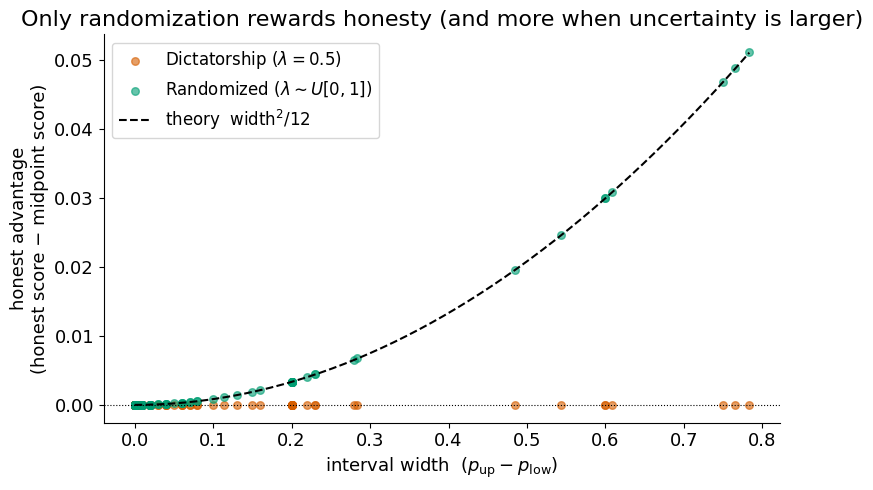

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df["width"], df["dict_advantage"],
           color="#D55E00", alpha=0.6, s=30, label="Dictatorship ($\\lambda=0.5$)")
ax.scatter(df["width"], df["rand_advantage"],
           color="#009E73", alpha=0.6, s=30, label="Randomized ($\\lambda\\sim U[0,1]$)")

# theory line: honest advantage = width^2 / 12
w_line = np.linspace(0, df["width"].max(), 200)
ax.plot(w_line, w_line**2 / 12, color="black", linestyle="--", linewidth=1.5,
        label=r"theory  $\mathrm{width}^2/12$")

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel(r"interval width  ($p_\mathrm{up} - p_\mathrm{low}$)", fontsize=13)
ax.set_ylabel("honest advantage\n(honest score − midpoint score)", fontsize=13)
ax.set_title("Only randomization rewards honesty (and more when uncertainty is larger)",
             fontsize=16)
ax.legend(fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "advantage_vs_width.pdf"), bbox_inches="tight", dpi=150)
plt.show()

> The red dictatorship points sit flat on zero at every width. The green randomized points start at zero (a width-zero interval *is* its own midpoint, so nothing to reward) and rise along the dashed $\text{width}^2/12$ curve. The fit is essentially exact because every $\lambda$ I draw is symmetric about $\tfrac12$. The interval's location does not enter, only its width. Most patients cluster near the origin (the easy cases honesty barely changes), and the few wide cases sit far right, where honesty pays the most.

## Step 8: Summary table (average expected scores)

In [29]:
mids = (credal_sets[:, 0] + credal_sets[:, 1]) / 2
strategies = {
    "Honest":   (credal_sets[:, 0], credal_sets[:, 1]),
    "Midpoint": (mids, mids),
}

summary = {}
for name, (q1s, q2s) in strategies.items():
    summary[name] = {
        "Dictatorship": np.mean([score_dictatorship(q1s[i], q2s[i],
                          credal_sets[i, 0], credal_sets[i, 1]) for i in range(len(y_test))]),
        "Randomized":   np.mean([score_randomized(q1s[i], q2s[i],
                          credal_sets[i, 0], credal_sets[i, 1]) for i in range(len(y_test))]),
    }

print(pd.DataFrame(summary).T.to_string(float_format="{:.6f}".format))

          Dictatorship  Randomized
Honest       -0.035857   -0.032758
Midpoint     -0.035857   -0.035857


> We can see that under **dictatorship**, honest and midpoint score identically (−0.035857) which is a perfect tie, faking precision is free. Under **randomized**, honest (−0.032758) beats midpoint (−0.035857) by 0.0031 so same number as the per-patient mean advantage, and the same $\mathbb{E}[w^2]/12$ law. The midpoint column is identical across both rules because a degenerate report is unaffected by how $\lambda$ is chosen.

---

## What I take from this

- **The randomized rule rewards honesty on real ensemble intervals**, and the reward scales with the width exactly as the closed form predicts. The synthetic law and the real-data scatter are the *same equation*.
- **Honesty pays precisely where uncertainty is real.** Most patients are easy (models agree, width ≈ 0), and there the incentive is near zero which is correct, there is nothing to hedge. The incentive switches on for the rare ambiguous patients, which is exactly where you would want a forecaster to be rewarded for admitting "I don't know."
- **Dictatorship is the control that proves the point.** Its honest advantage is identically zero, so the gap between the two rules isolates the effect of randomization and nothing else.

> **On expected vs. realized scores.** Strict properness is about the expected payoff under the forecaster's own belief, before the outcome. On any single patient the realized outcome can favour a different report, that is normal. The same way a positive-expected-value bet can still lose a single trial. So I report expected scores throughout; the realized outcome of one patient is not what the theorem is about.